In [1]:
import pandas as pd
import numpy as np
import torch
import importlib
from importlib import reload
import os
import sys
sys.path.append(os.path.abspath('../../'))
from protocol import ScoreSpectra, BayesianOptimization,GaussianProcess, PlotGP, MaraData,TxtToCsvConverter
import itertools
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import re
from scipy.stats import qmc
import random

dtype = torch.float64

In [2]:
# PbI2:BAAc:MAI = 1 : (2/n) : [(n+1)/n]
theoretical_N2 = {'Anneal Time': 10, # min
                  'Temperature': 150, # C
                  'R BAAc': 1.00,  
                  'R MAI': 1.50,
                  'R PbI2': 1,
                  }

# PbI2:BAAc:MAI = 1 : (2/n) : [(n+1)/n]
theoretical_N1 = {'Anneal Time': 10, # min
                  'Temperature': 150, # C
                  'R BAAc': 2.00,  
                  'R MAI': 2.00,
                  'R PbI2': 1,
                  }

# PbI2:BAAc:MAI = 1 : (2/n) : [(n+1)/n]
theoretical_N3 = {'Anneal Time': 10, # min
                  'Temperature': 150, # C
                  'R BAAc': 0.667,  # aprox to 0.675
                  'R MAI': 1.333, # aprox to 1.325
                  'R PbI2': 1,
                  }

theoretical_N4 = {'Anneal Time': 10, # min
                  'Temperature': 95, # C
                  'R BAAc': 0.5,  
                  'R MAI': 1.25,
                  'R PbI2': 1,
                  }

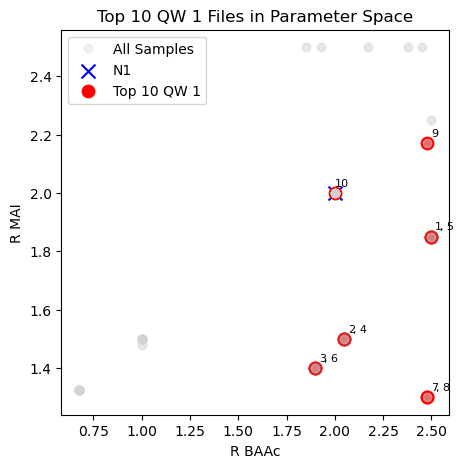

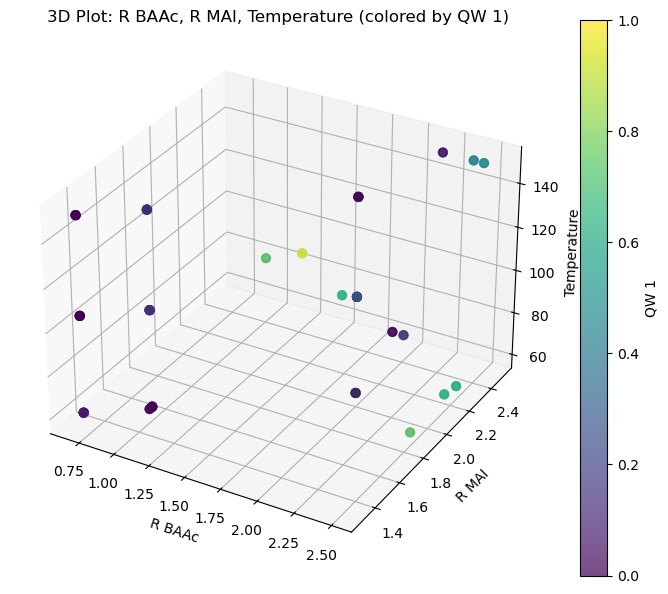

In [3]:
previous_data = pd.read_csv('../N1_Campaign/Data/N1Campaign_data.csv')
top10 = previous_data.nlargest(10, 'QW 1')[['Anneal Time','Temperature','R BAAc', 'R MAI', 'QW 1', 'files']]
theoretical10_N1 = previous_data[['Anneal Time','Temperature','R BAAc', 'R MAI', 'QW 1', 'files']]
theoretical10_N1 = theoretical10_N1[theoretical10_N1['R MAI'] == 2.0]


plt.figure(figsize=(5,5))
plt.plot(previous_data['R BAAc'], previous_data['R MAI'], 'o', color='lightgrey', label='All Samples', alpha=0.3)
plt.scatter(theoretical_N1['R BAAc'], theoretical_N1['R MAI'], marker='x', color='blue', s=100, label='N1')
plt.scatter(top10['R BAAc'], top10['R MAI'], color='red', s=80, label='Top 10 QW 1')
plt.scatter(top10['R BAAc'].iloc[:3], top10['R MAI'].iloc[:3], color='tab:red', s=80)

coord_counts = {}
for i, (_, row) in enumerate(top10.iterrows(), start=1):
    key = (round(row['R BAAc'], 3), round(row['R MAI'], 3))
    count = coord_counts.get(key, 0)
    if count == 0:
        xytext = (5, 5)
        ha = 'center'
        ann_label = str(i)
    else:
        ann_label = ', '+str(i)
        # place duplicate annotations to the right of the previous one, shifting further for each duplicate
        xytext = ( 6*count, 5)
        ha = 'left'
    plt.annotate(ann_label,
                 (row['R BAAc'], row['R MAI']),
                 fontsize=8,
                 xytext=xytext,
                 textcoords='offset points',
                 ha=ha,
                 color='black')
    coord_counts[key] = count + 1


plt.xlabel('R BAAc')
plt.ylabel('R MAI')
plt.title('Top 10 QW 1 Files in Parameter Space')
plt.legend()
# plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(previous_data['R BAAc'], previous_data['R MAI'], previous_data['Temperature'], 
           c=previous_data['QW 1'], cmap='viridis', s=40, alpha=0.7)
ax.set_xlabel('R BAAc')
ax.set_ylabel('R MAI')
ax.set_zlabel('Temperature')
ax.set_title('3D Plot: R BAAc, R MAI, Temperature (colored by QW 1)')
plt.colorbar(ax.collections[0], ax=ax, label='QW 1')
plt.tight_layout()
plt.show()



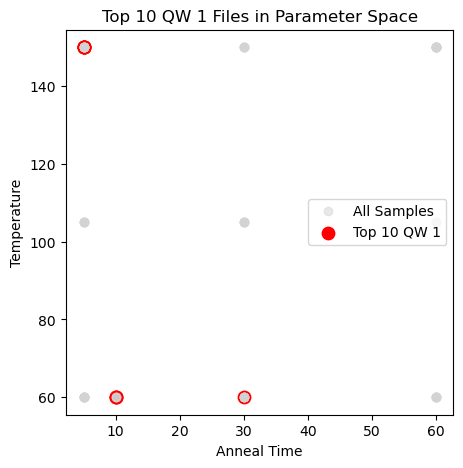

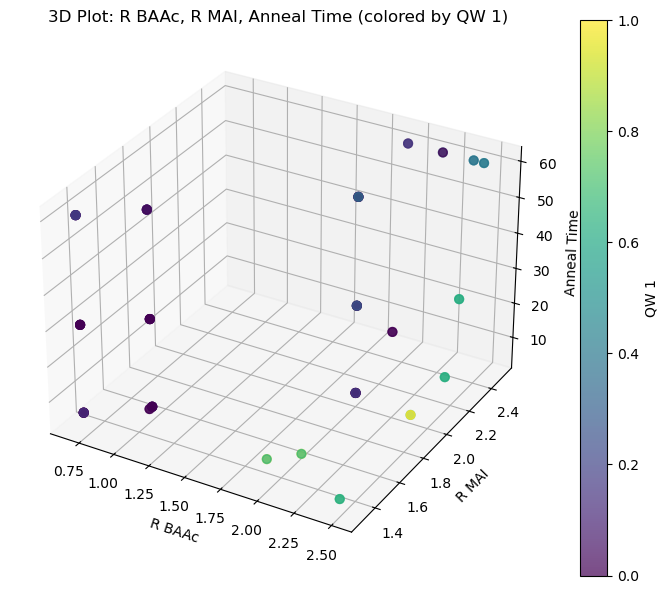

In [4]:
plt.figure(figsize=(5,5))
plt.plot(previous_data['Anneal Time'], previous_data['Temperature'], 'o', color='lightgrey', label='All Samples', alpha=0.5)
plt.scatter(top10['Anneal Time'], top10['Temperature'], color='red', s=80, label='Top 10 QW 1')
# for idx, row in top10.iterrows():
#     plt.annotate(row['files'], (row['Anneal Time'], row['Temperature']), fontsize=8, xytext=(5,5), textcoords='offset points')
plt.xlabel('Anneal Time')
plt.ylabel('Temperature')
plt.title('Top 10 QW 1 Files in Parameter Space')
plt.legend()
# plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(previous_data['R BAAc'], previous_data['R MAI'], previous_data['Anneal Time'], 
           c=previous_data['QW 1'], cmap='viridis', s=40, alpha=0.7)
ax.set_xlabel('R BAAc')
ax.set_ylabel('R MAI')
ax.set_zlabel('Anneal Time')
ax.set_title('3D Plot: R BAAc, R MAI, Anneal Time (colored by QW 1)')
plt.colorbar(ax.collections[0], ax=ax, label='QW 1')
plt.tight_layout()
plt.show()

In [5]:
top10

,Anneal Time,Temperature,R BAAc,R MAI,QW 1,files
61,10.0,60.0,2.50,1.85,1.000000,N1 R1 sample 8_Subt2__0__11-28-34-871.csv
73,5.0,150.0,2.05,1.50,1.000000,N1 R2 sample 8_Subt2__0__12-59-07-751.csv
74,5.0,150.0,1.90,1.40,1.000000,N1 R2 sample 9_Subt2__0__12-59-25-750.csv
72,5.0,150.0,2.05,1.50,0.649397,N1 R2 sample 7_Subt2__0__12-58-36-751.csv
60,10.0,60.0,2.50,1.85,0.641476,N1 R1 sample 7_Subt2__0__11-28-12-362.csv
75,5.0,150.0,1.90,1.40,0.641111,N1 R2 sample 10_Subt2__0__13-00-22-249.csv
76,5.0,150.0,2.48,1.30,0.637731,N1 R2 sample 11_Subt2__0__13-00-52-248.csv
77,5.0,150.0,2.48,1.30,0.637427,N1 R2 sample 12_Subt2__0__13-01-43-748.csv
59,10.0,60.0,2.48,2.17,0.635232,N1 R1 sample 6_Subt2__0__11-27-48-374.csv
38,30.0,60.0,2.00,2.00,0.634724,N1 R0 60C sample 5_Subt2__0__12-01-57-269.csv


[OK] Found file: ../N1_Campaign/Data/20250917_N1R1/N1 R1 sample 8_Subt2__0__11-28-34-871.csv
[OK] Found file: ../N1_Campaign/Data/20250917_N1R2/N1 R2 sample 8_Subt2__0__12-59-07-751.csv
[OK] Found file: ../N1_Campaign/Data/20250917_N1R2/N1 R2 sample 9_Subt2__0__12-59-25-750.csv
[OK] Found file: ../N1_Campaign/Data/20250917_N1R2/N1 R2 sample 7_Subt2__0__12-58-36-751.csv
[OK] Found file: ../N1_Campaign/Data/20250917_N1R1/N1 R1 sample 7_Subt2__0__11-28-12-362.csv
[OK] Found file: ../N1_Campaign/Data/20250917_N1R2/N1 R2 sample 10_Subt2__0__13-00-22-249.csv
[OK] Found file: ../N1_Campaign/Data/20250917_N1R2/N1 R2 sample 11_Subt2__0__13-00-52-248.csv
[OK] Found file: ../N1_Campaign/Data/20250917_N1R2/N1 R2 sample 12_Subt2__0__13-01-43-748.csv
[OK] Found file: ../N1_Campaign/Data/20250917_N1R1/N1 R1 sample 6_Subt2__0__11-27-48-374.csv
[OK] Found file: ../N1_Campaign/Data/20250916_N1N3_N1R060C/N1 R0 60C sample 5_Subt2__0__12-01-57-269.csv


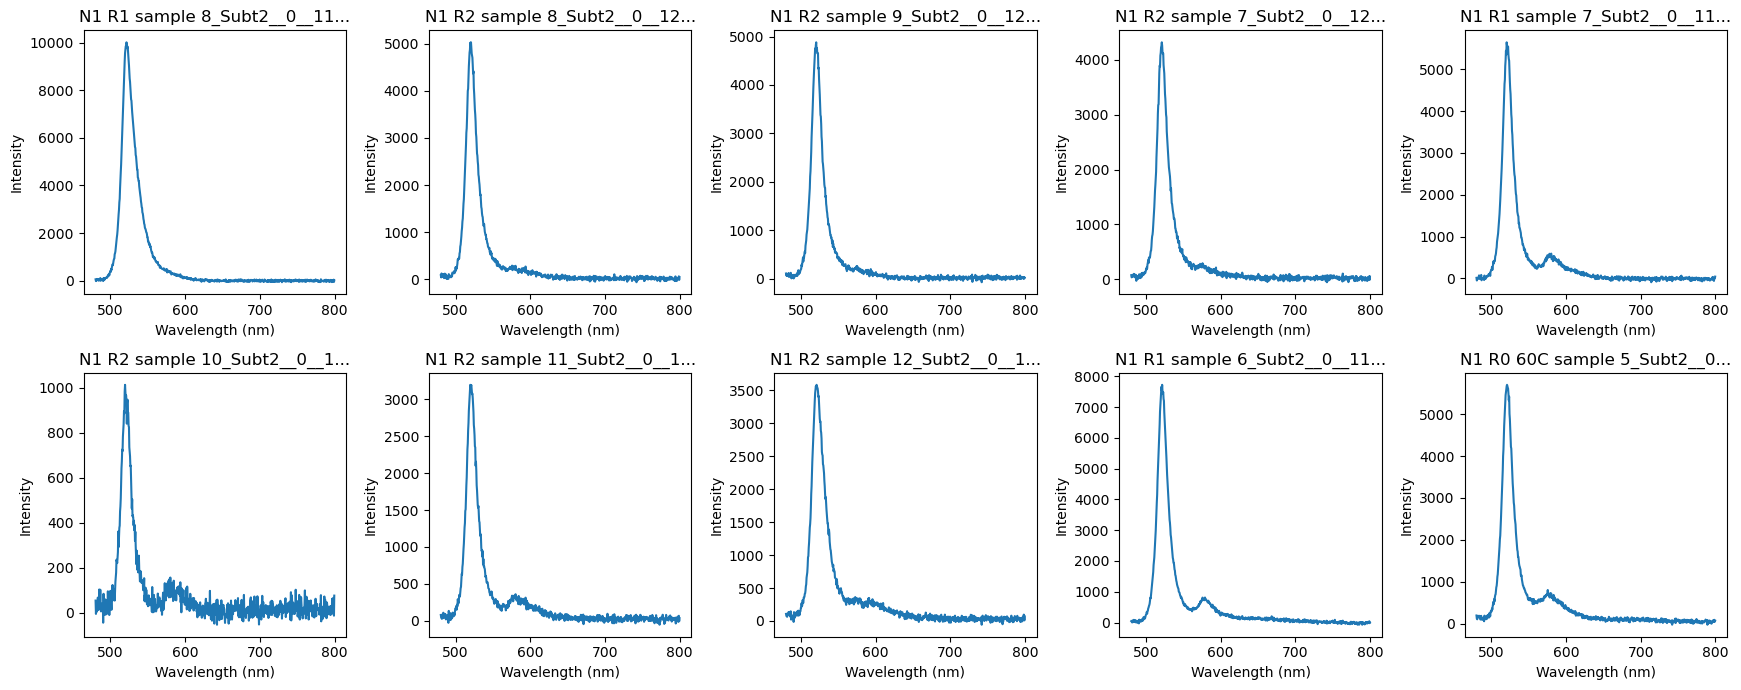

In [6]:
from protocol.query_data import FileLocator  # if saved as file_locator.py

locator = FileLocator(base_dir="../N1_Campaign/Data/", prefix_len=6)

file_paths = locator.locate_files(top10['files'].tolist())

locator.plot_spectra(file_paths)



[~] Using closest CSV match:
    N1 R0 60C sample 1_Subt2__0__12-25-40-737.csv
[~] Using closest CSV match:
    N1 R0 60C sample 2_Subt2__0__12-26-44-236.csv
[~] Using closest CSV match:
    N1 R0 60C sample 5_Subt2__0__12-01-57-269.csv
[~] Using closest CSV match:
    N1 R0 60C sample 6_Subt2__0__11-59-59-271.csv
[~] Using closest CSV match:
    N1 R0 60C sample 9_Subt2__0__11-34-26-305.csv
[~] Using closest CSV match:
    N1 R0 60C sample 10_Subt2__0__11-35-42-304.csv
[~] Using closest CSV match:
    N1R0 105C sample 1_Subt2__0__13-38-18-639.csv
[~] Using closest CSV match:
    N1R0 105C sample 2_Subt2__0__13-38-46-638.csv
[~] Using closest CSV match:
    N1R0 105C sample 5_Subt2__0__13-11-29-175.csv
[~] Using closest CSV match:
    N1R0 105C sample 6_Subt2__0__13-12-29-674.csv
[~] Using closest CSV match:
    N1R0 105C sample 9_Subt2__0__12-54-00-698.csv
[~] Using closest CSV match:
    N1R0 105C sample 10_Subt2__0__12-49-55-204.csv
[~] Using closest CSV match:
    N1R0 150C sample 

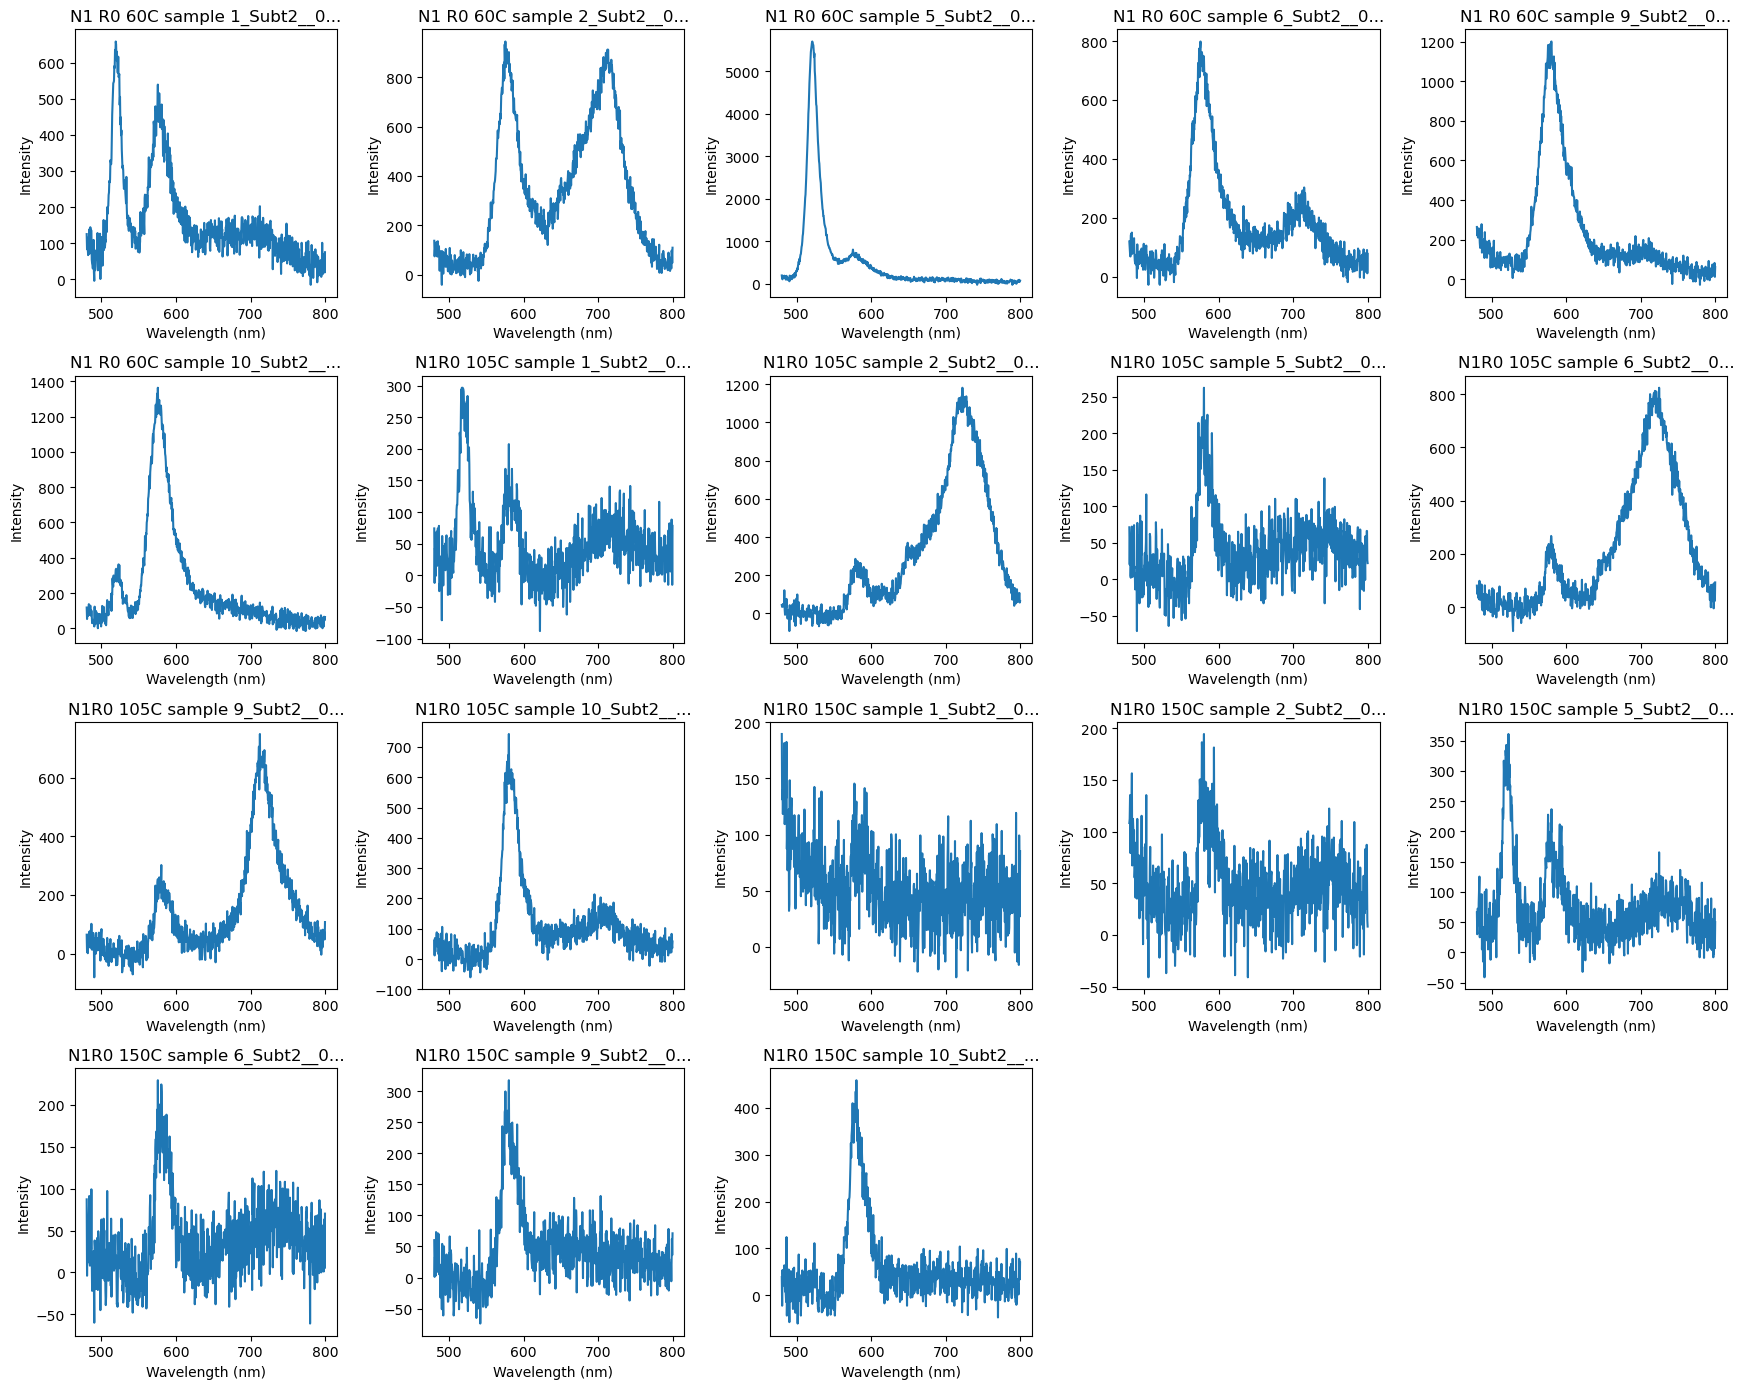

In [7]:

locator = FileLocator(base_dir="../N1_Campaign/Data/", prefix_len=9)

file_paths = locator.locate_closest_files(theoretical10_N1['files'].tolist())

locator.plot_spectra(file_paths, color='tab:blue')


In [8]:
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# # --- Coordinates for the scatter ---
# x = row["R BAAc"]
# y = row["R MAI"]
# filepath = locator.plot_spectra(file_paths)


# # --- Read the spectra file ---
# spec = pd.read_csv(filepath, names=["wavelength", "intensity"], header=None)

# # --- Main plot ---
# fig, ax = plt.subplots(figsize=(7, 6))
# ax.scatter(x, y, s=200, color="red", edgecolor="k", zorder=3)
# ax.set_xlabel("R BAAc")
# ax.set_ylabel("R MAI")
# ax.set_title("Sample location with spectrum inset")

# # --- Add small spectrum inset located at that point ---
# # size = width%, height% of the parent
# inset = inset_axes(ax, width="30%", height="30%", 
#                     loc='center',
#                     bbox_to_anchor=(x, y),
#                     bbox_transform=ax.transData,
#                     borderpad=0)

# inset.plot(spec["wavelength"], spec["intensity"])
# inset.set_xticks([])
# inset.set_yticks([])
# inset.set_title("Spectrum", fontsize=8)

# # Connect the inset to the point (optional)
# ax.plot([x, x], [y, y], marker="o", color="red")

# plt.show()


In [9]:
# import os
# import subprocess

# directory = '../N1_Campaign/Data/'  # adjust this path if needed

# file_paths = []
# for fname in top10['files']:
#     if fname[:6]:
#         # Find the folder in directory that contains the name 
#         folders = [f for f in os.listdir(directory) if os.path.isdir(os.path.join(directory, f)) and fname[:6].replace(" ", "") in f]
#         print(folders)
#         if folders:
#             folder_path = os.path.join(directory, folders[0])
#             print(f"Opening folder: {folder_path}")
#             file_path = os.path.join(folder_path, fname)
#             if os.path.exists(file_path):
#                 print('file found, saving file_path')
#                 file_paths.append(file_path)
#         else:
#             print(f"No folder containing '{fname}' found in directory.")

# # file_paths.append('N1_Sep/Data/20250916_N1N3_105C/N1 R0 105C sample 2_Subt2__1__13-38-47-638.csv')
# file_paths.append('../N1_Campaing/Data/20250916_N1N3_60C/N1 R0 60C sample 5_Subt2__0__12-01-57-269.csv')

ValueError: num must be an integer with 1 <= num <= 10, not 11

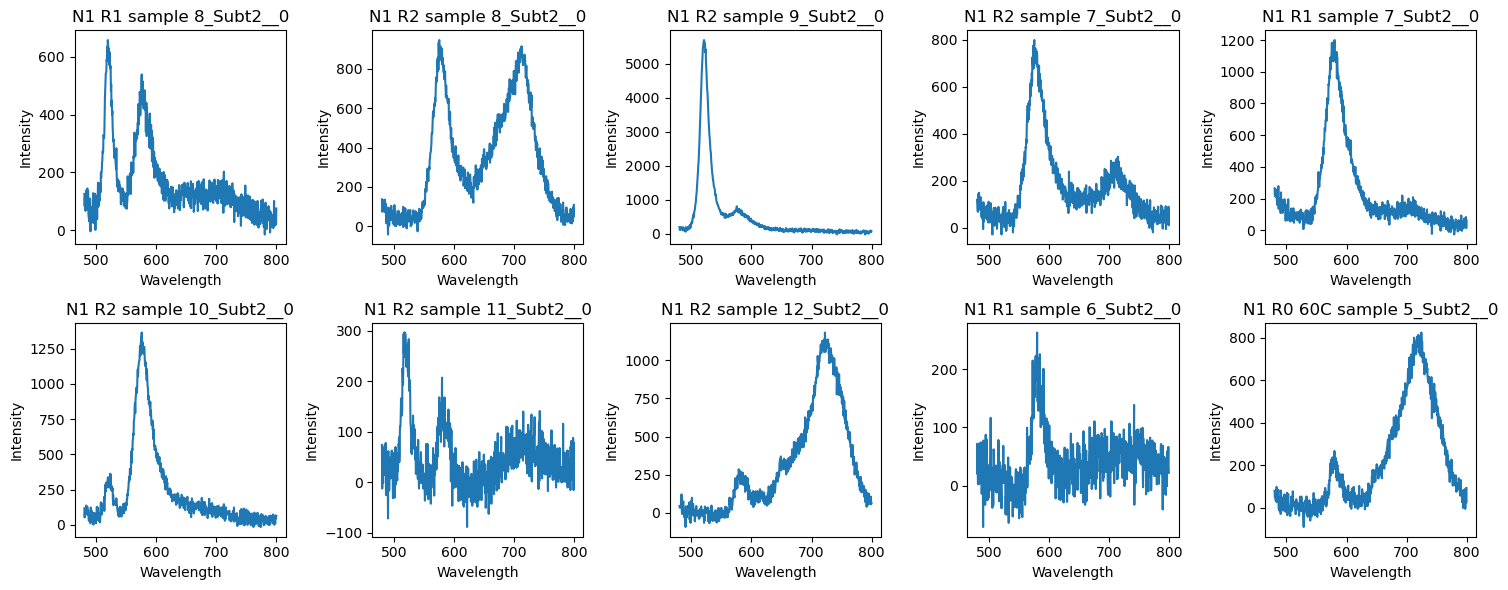

In [10]:
plt.figure(figsize=(15,6))
for i in range(len(file_paths)):
    df = pd.read_csv(file_paths[i], names=['wavelength', 'intensity'])
    df = df[(df['wavelength'] >= 480) & (df['wavelength'] <= 800)]

    plt.subplot(2, 5, i+1)
    plt.plot(df['wavelength'], df['intensity'])
    plt.title(top10['files'].iloc[i][:-18])
    plt.xlabel('Wavelength')
    plt.ylabel('Intensity')
    plt.tight_layout()

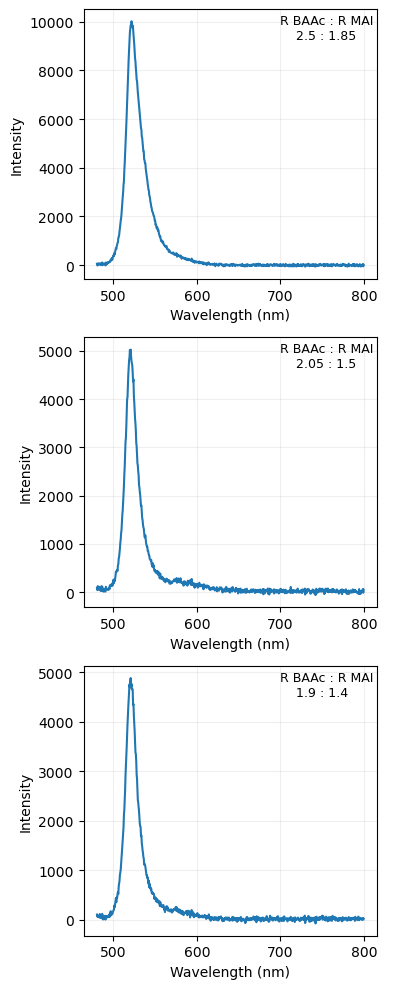

In [ ]:
# Plot top 3 spectra as subplots
n = 3
plt.figure(figsize=(4, 10))
for idx in range(n):
    fp = file_paths[idx]
    spec = pd.read_csv(fp, names=['wavelength', 'intensity'])
    spec = spec[(spec['wavelength'] >= 480) & (spec['wavelength'] <= 800)]

    ax = plt.subplot(n,1,idx + 1)
    ax.plot(spec['wavelength'], spec['intensity'])
    title = top10['files'].iloc[idx]
    # ax.set_title(title[:-18] if len(title) > 18 else title)
    ax.set_xlabel('Wavelength (nm)')
    # if idx == 0:
    ax.set_ylabel('Intensity')
    qval = top10['QW 1'].iloc[idx]
    ax.annotate(f"R BAAc : R MAI   \n    {top10['R BAAc'].iloc[idx]} : {top10['R MAI'].iloc[idx]}",xy=(0.67, 0.93), xycoords='axes fraction', va='center', fontsize=9)
    ax.grid(alpha=0.2)
    

plt.tight_layout()
plt.show()

In [ ]:
# Past experimental data loading
previous_data= pd.read_csv('../N1_Sep/Data/N1Campaign_data.csv')
previous_data = previous_data[['Anneal Time','Temperature','R BAAc', 'R MAI', 'R PbI2', 'QW 1']]
R0_df = previous_data[['Anneal Time','R PbI2','R BAAc', 'R MAI', 'Temperature']][::2].reset_index(drop=True)

QW2_mean = previous_data['QW 1'].groupby(previous_data.index // 2).mean().reset_index(drop=True)
QW2_var = previous_data['QW 1'].groupby(previous_data.index // 2).var().reset_index(drop=True)
R0_df['QW 1 mean'] = QW2_mean
R0_df['QW 1 var'] = QW2_var

fig, axs = plt.subplots(1, 4, figsize=(15, 3))
variables = ['Anneal Time', 'Temperature', 'R BAAc', 'R MAI']
titles = ['Anneal Time vs QW 1', 'Temp vs QW 1', 'R BAAc vs QW 1', 'R MAI vs QW 1']

for ax, var, title in zip(axs.flatten(), variables, titles):
    scatter = ax.scatter(R0_df[var], R0_df['QW 1 mean'], c=R0_df['QW 1 mean'], cmap='viridis', label='mean')
    ax.errorbar(R0_df[var], R0_df['QW 1 mean'], yerr=R0_df['QW 1 var']**0.5, fmt='none', ecolor='gray', alpha=0.5)
    ax.set_xlabel(var)
    
    ax.set_title(title)
    plt.colorbar(scatter, ax=ax, label='QW 1 mean')

plt.tight_layout()
plt.show()

In [ ]:
# Set up for GP and BO
dtype = torch.float64
original_bounds = torch.tensor([[5, 60], [60, 150],[0.6, 2.5],[1.3, 2.5]], dtype=dtype) # Time, temp, R BAAc, R MAI

# Set up of the traning data
train_X = R0_df[['Anneal Time','Temperature','R BAAc', 'R MAI']].to_numpy()
train_y = R0_df['QW 1 mean'].to_numpy()
train_yvar = R0_df['QW 1 var'].to_numpy() # Use the mean of QW 3 for training

gaussian = GaussianProcess(train_X, train_y, train_yvar=train_yvar,bounds = original_bounds.T)
gaussian.fit()

x = np.linspace(0, 1, 50) 
y = np.linspace(0, 1, 50) 
A, B = np.meshgrid(x, y)
# Define slices across a third variable
c_slices = np.linspace(0.0, 1.0, 10)  # 5 slices for the third variable
d_fixed = [0.0, 0.25, 0.5, 0.75, 1.0] # Fixed value for the fourth variable

plot_bounds = torch.tensor([[0.0, 0.0, 0.0, 0.0] , [1.0, 1.0, 1.0, 1.0]], dtype=dtype)
plotter = PlotGP(gaussian, plot_bounds)
combination = ('R BAAc', 'R MAI', 'Anneal Time')  # Example: (A, B, c) maps to ('time', 'sulf', 'anly')

plotter.sliced_4D_plotting(A, B, c_slices, d_fixed, combination, colormap='Viridis', minmax=(0, 1))
plotter.sliced_4D_plotting(A, B, c_slices, d_fixed, combination, colormap='Viridis_r', minmax=(0, 1), plot_type='variance')


NameError: name 'R0_df' is not defined

In [ ]:
def plot_next_round(all_data):
    # Create 3 subplots: first is 3D, others are 2D
    fig = plt.figure(figsize=(16, 5))
    ax3d = fig.add_subplot(131, projection='3d')
    ax2d_1 = fig.add_subplot(132)
    ax2d_2 = fig.add_subplot(133)
    axs = [ax3d, ax2d_1, ax2d_2]

    variables = [['Anneal Time', 'Temperature'], ['R BAAc', 'R MAI']]
    titles = ['Anneal Time vs Temperature', 'R BAAc vs R MAI']

    # 3D scatter plot
    sc = ax3d.scatter(all_data['R BAAc'], all_data['R MAI'], all_data['Temperature'], c=all_data['QW 1 mean'], cmap='viridis', alpha=0.8)
    
    ax3d.set_ylabel('R MAI')
    ax3d.set_zlabel('Temperature')
    ax3d.set_title('3D Scatter: R BAAc vs R MAI vs Temperature')
    for i, row in all_data.iterrows():
        ax3d.text(row['R BAAc'], row['R MAI'], row['Temperature'], f"{int(row['Anneal Time'])}", size=7, color='black', alpha=0.6)
    plt.colorbar(sc, ax=ax3d, label='QW 1 mean')
    plt.tight_layout()

    # 2D scatter plots
    for ax, var_pair, title in zip(axs[1:], variables, titles):
        sc = ax.scatter(all_data[var_pair[0]], all_data[var_pair[1]], c=all_data['QW 1 mean'], cmap='viridis', alpha=0.7)
        ax.scatter(theoretical_N1[var_pair[0]], theoretical_N1[var_pair[1]], color='red', marker='x', s=100, label='N1')
        ax.annotate('N1', (theoretical_N1[var_pair[0]], theoretical_N1[var_pair[1]]), xytext=(0, 10), textcoords='offset points', ha='center', color='red', fontsize=10)
        ax.set_xlabel(var_pair[0])
        ax.set_ylabel(var_pair[1])
        ax.set_title(title)
        plt.colorbar(sc, ax=ax, label='Score')
        if var_pair == ['Anneal Time', 'Temperature']:
            for i, row in all_data.iterrows():
                ax.annotate(f"({row['R BAAc']:.2f},{row['R MAI']:.2f})",
                            (row[var_pair[0]], row[var_pair[1]]),
                            textcoords="offset points", xytext=(3,3), ha='center', fontsize=7, alpha=0.5)
        else:
            for i, row in all_data.iterrows():
                ax.annotate(f"({int(row['Anneal Time'])},{int(row['Temperature'])})",
                            (row[var_pair[0]], row[var_pair[1]]),
                            textcoords="offset points", xytext=(3,3), ha='center', fontsize=7, alpha=0.5)

    plt.tight_layout()
    plt.show()


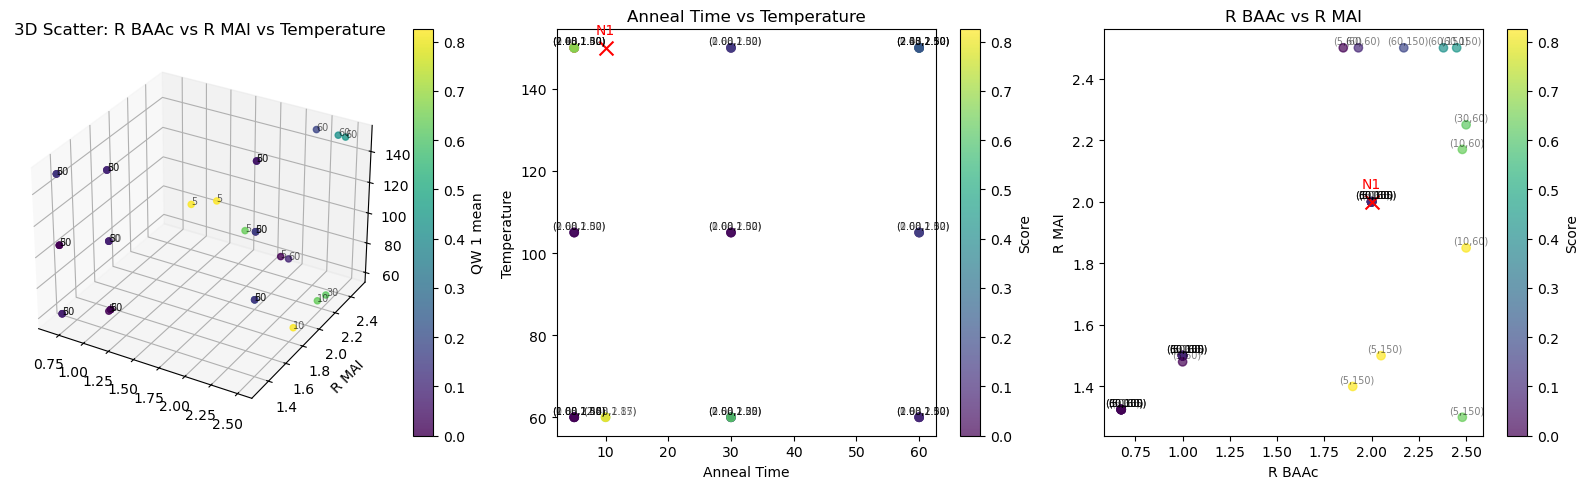

In [ ]:
plot_next_round(R0_df)

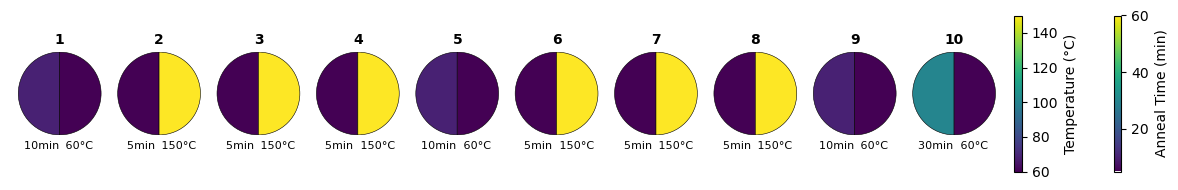

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.cm import ScalarMappable

fig, ax = plt.subplots(figsize=(12, 2))

n = len(top10)
radius = 0.5
y = 0.5
x_spacing = 1.2

# arrays for normalization
temps = top10['Temperature'].to_numpy()
times = top10['Anneal Time'].to_numpy()

# colormaps for left (time) and right (temperature)
time_cmap = plt.cm.viridis
temp_cmap = plt.cm.viridis

for i in range(n):
    cx = i * x_spacing + radius + 0.1
    row = top10.iloc[i]
    temp = row['Temperature']
    time_ = row['Anneal Time']

    # normalize to [0,1] for colormap lookup
    timenorm = (time_ - original_bounds[0, 0]) / (original_bounds[1, 0] - original_bounds[0, 0]) if original_bounds[1, 0] > original_bounds[0, 0] else 0.5
    tnorm = (temp - original_bounds[1, 0]) / (original_bounds[1, 1] - original_bounds[1, 0]) if original_bounds[1, 1] > original_bounds[1, 0] else 0.5

    left_color = time_cmap(timenorm)     # left = time
    right_color = temp_cmap(tnorm)       # right = temperature

    left = mpatches.Wedge(center=(cx, y), r=radius, theta1=90, theta2=270, color=left_color, ec='k', lw=0.4)
    right = mpatches.Wedge(center=(cx, y), r=radius, theta1=-90, theta2=90, color=right_color, ec='k', lw=0.4)
    ax.add_patch(left)
    ax.add_patch(right)

# colorbars: map to original value ranges for clarity
sm_time = ScalarMappable(cmap=time_cmap, norm=plt.Normalize(vmin=original_bounds[0, 0], vmax=original_bounds[0, 1]))
sm_time.set_array([])
cbar_time = fig.colorbar(sm_time, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
cbar_time.set_label('Anneal Time (min)')

sm_temp = ScalarMappable(cmap=temp_cmap, norm=plt.Normalize(vmin=original_bounds[1, 0], vmax=original_bounds[1, 1]))
sm_temp.set_array([])
cbar_temp = fig.colorbar(sm_temp, ax=ax, orientation='vertical', fraction=0.05, pad=0.01)
cbar_temp.set_label('Temperature (°C)')

# add annotations above each semicircle (time on left, temp on right)
def _fmt(v):
    fv = float(v)
    return f"{int(fv)}" if fv.is_integer() else f"{fv:.1f}"

def _text_color(c):
    r, g, b, _ = c
    lum = 0.299 * r + 0.587 * g + 0.114 * b
    return 'k' if lum < 0.5 else 'k'

y_text = y - radius * 1.4  # place annotations above the semicircles

for i in range(n):
    cx = i * x_spacing + radius + 0.1
    row = top10.iloc[i]
    temp = row['Temperature']
    time_ = row['Anneal Time']

    timenorm = (time_ - original_bounds[0, 0]) / (original_bounds[1, 0] - original_bounds[0, 0]) if original_bounds[1, 0] > original_bounds[0, 0] else 0.5
    tnorm = (temp - original_bounds[1, 0]) / (original_bounds[1, 1] - original_bounds[1, 0]) if original_bounds[1, 1] > original_bounds[1, 0] else 0.5

    left_color = time_cmap(timenorm)
    right_color = temp_cmap(tnorm)

    # add sequential numeric label below each semicircle (left-to-right)
    ax.text(cx, y + radius * 1.3, str(i + 1), ha='center', va='center', fontsize=10, fontweight='bold', color='k')

    ax.text(cx - radius * 0.40, y_text, _fmt(time_) + "min ",
            ha='center', va='bottom', fontsize=8, color=_text_color(left_color))
    ax.text(cx + radius * 0.35, y_text,'   '+ _fmt(temp) + "°C",
            ha='center', va='bottom', fontsize=8, color=_text_color(right_color))
    
ax.set_xlim(0, n * x_spacing)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()


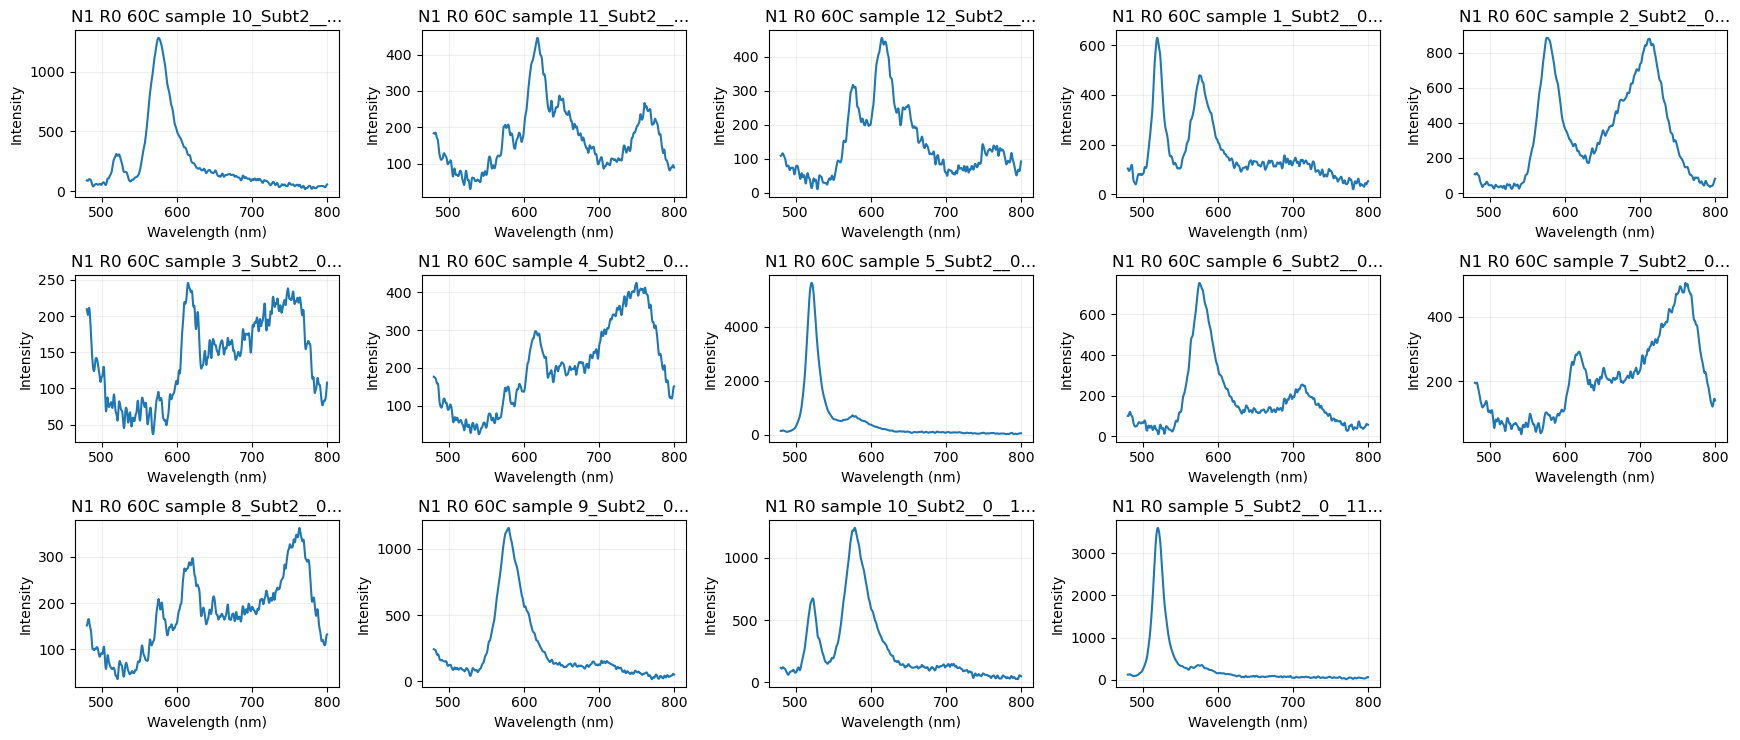

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import math
from pathlib import Path
import re

directory = '../N1_Sep/Data/20250916_N1N3_60C'  # adjust this path if needed
sigma = 2.0  # adjust smoothing strength

root = Path(directory)
exts = ('.csv', '.txt')
all_files = sorted([p for p in root.rglob('*') if p.suffix.lower() in exts])

if not all_files:
    print(f"No .csv/.txt files found under {directory}")
else:
    # --- Choose the first of each unique sample (run index == 0 after _Subt2__) ---
    # Example filename: "N1 R0 60C sample 1_Subt2__0__12-25-40-737.csv"
    # Group key = everything up to and including "sample N_Subt2__"
    # Prefer run==0; if not present, take the lowest run number.
    pattern = re.compile(r'^(?P<prefix>.*?sample\s*\d+_Subt2__)(?P<run>\d+)__.*$', re.IGNORECASE)

    best = {}  # key: prefix, value: (Path, run)
    for p in all_files:
        m = pattern.match(p.stem)
        if not m:
            # If a file doesn't match the expected pattern, skip it.
            continue
        key = m.group('prefix')
        try:
            run = int(m.group('run'))
        except ValueError:
            continue

        if key not in best:
            best[key] = (p, run)
        else:
            chosen_p, chosen_run = best[key]
            # Prefer run == 0; otherwise keep the lowest run number seen
            if chosen_run != 0 and (run == 0 or run < chosen_run):
                best[key] = (p, run)

    selected_files = [t[0] for t in best.values()]
    selected_files.sort(key=lambda x: x.name)  # optional: stable ordering

    if not selected_files:
        print("No files matched the pattern '*sample N_Subt2__<run>__*.csv'.")
    else:
        # --- Plot setup ---
        n = len(selected_files)
        cols = 5
        rows = math.ceil(n / cols)
        plt.figure(figsize=(cols * 3.5, rows * 2.5))

        for i, p in enumerate(selected_files):
            try:
                spec = pd.read_csv(p, names=['wavelength', 'intensity'], header=None, comment='#')
                # try to coerce to numeric; fallback to tab/comma-separated parsing if intensity is all NaN
                spec['wavelength'] = pd.to_numeric(spec['wavelength'], errors='coerce')
                spec['intensity'] = pd.to_numeric(spec['intensity'], errors='coerce')
                if spec['intensity'].isna().all() or spec['wavelength'].isna().all():
                    spec = pd.read_csv(p, sep=r'[\t,]+', names=['wavelength', 'intensity'], header=None, engine='python')
                    spec['wavelength'] = pd.to_numeric(spec['wavelength'], errors='coerce')
                    spec['intensity'] = pd.to_numeric(spec['intensity'], errors='coerce')
                spec = spec.dropna(subset=['wavelength', 'intensity'])
                spec = spec[(spec['wavelength'] >= 480) & (spec['wavelength'] <= 800)]
                if spec.empty:
                    print(f"Skipping {p.name}: no valid data in 480–800 nm range")
                    continue
            except Exception as e:
                print(f"Skipping {p.name}: read error ({e})")
                continue

            # apply Gaussian smoothing to intensity
            smoothed_intensity = gaussian_filter1d(spec['intensity'].values, sigma=sigma)

            ax = plt.subplot(rows, cols, i + 1)
            ax.plot(spec['wavelength'], smoothed_intensity)
            title = p.name
            ax.set_title(title if len(title) <= 30 else title[:27] + '...')
            ax.set_xlabel('Wavelength (nm)')
            ax.set_ylabel('Intensity')
            ax.grid(alpha=0.2)

        plt.tight_layout()
        plt.show()
